# PART1 DATENQUALITÄT

### Missingness
Um herauszufinden, wie vollstämdig die Daten sind, prüfen wir die Daten auf Missingness. Da es sich bei unserer Missingness zu einem grossen Teil um MAR und teils auch MNAR handelt, ist es schwierig, die Missingness zu behandeln. Wir haben uns desshalb entschieden , die Missingness nur zu dokumentieren und nicht zu behandeln. Da wir im Jahre 2017 die meisten Daten haben, beziehen wir uns auf dieses Jahr

### Matching WHO ↔ World Bank
Damit wir die Verschiedenen Länder vergleichen können, müssen wir die Daten normalisieren. Dazu verwemden wir die Bevölkerung von jedem Land aus der World Bank. Damit wir die Daten zusammenführen können, müssen wir die Ländernamen in beiden Datensätzen abgleichen, und können damach die Anzahl Todesfälle pro 100'000 Einwohner berechnen.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pycountry
import seaborn as sns

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df = pd.read_csv('Data_Files\\base_data104_with_lookup.csv')

df_period = df[(df["Year"] >= 2010) & (df["Year"] <= 2024)]


missing_counts = df_period.isna().sum()

C:\Users\benma\AppData\Local\Temp\ipykernel_28572\4106284821.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year = df_period.groupby("Year").apply(lambda x: x.isna().sum().sum())


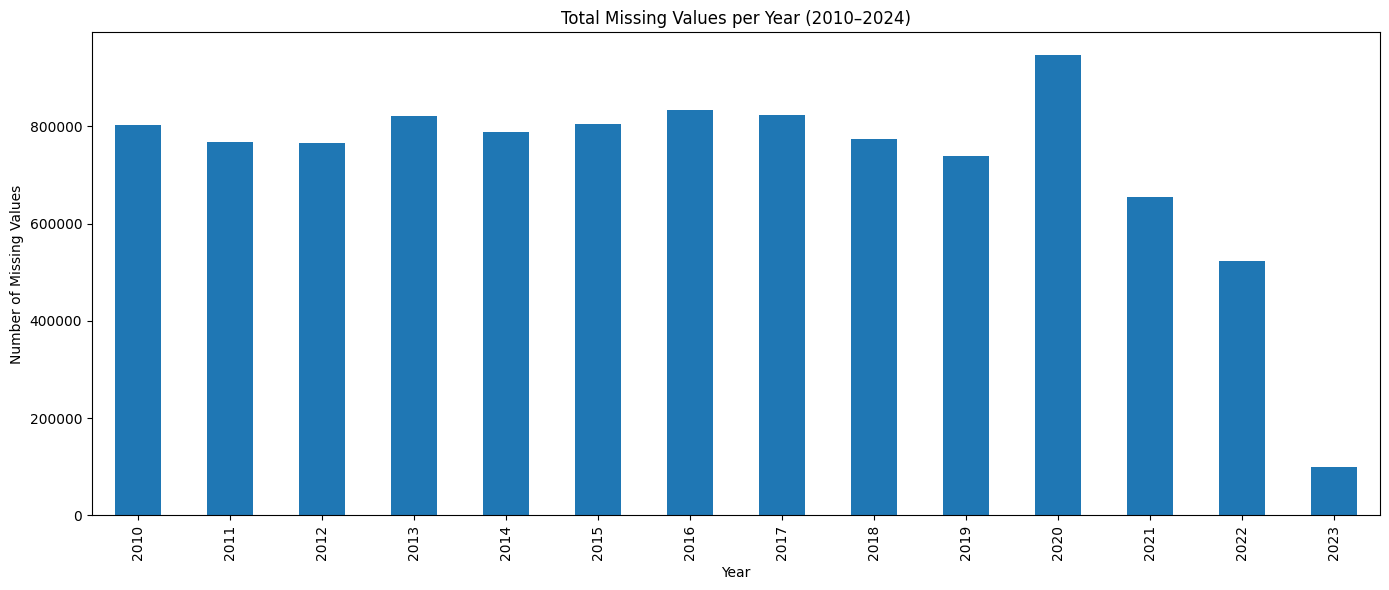

In [3]:
# Missing Values pro Jahr berechnen
missing_by_year = df_period.groupby("Year").apply(lambda x: x.isna().sum().sum())

# In ein DataFrame umwandeln, damit es für eine Heatmap passt
missing_df = missing_by_year.to_frame(name="Missing Values")


plt.figure(figsize=(14, 6))
missing_by_year.plot(kind="bar")
plt.title("Total Missing Values per Year (2010–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Missing Values")
plt.tight_layout()
plt.show()

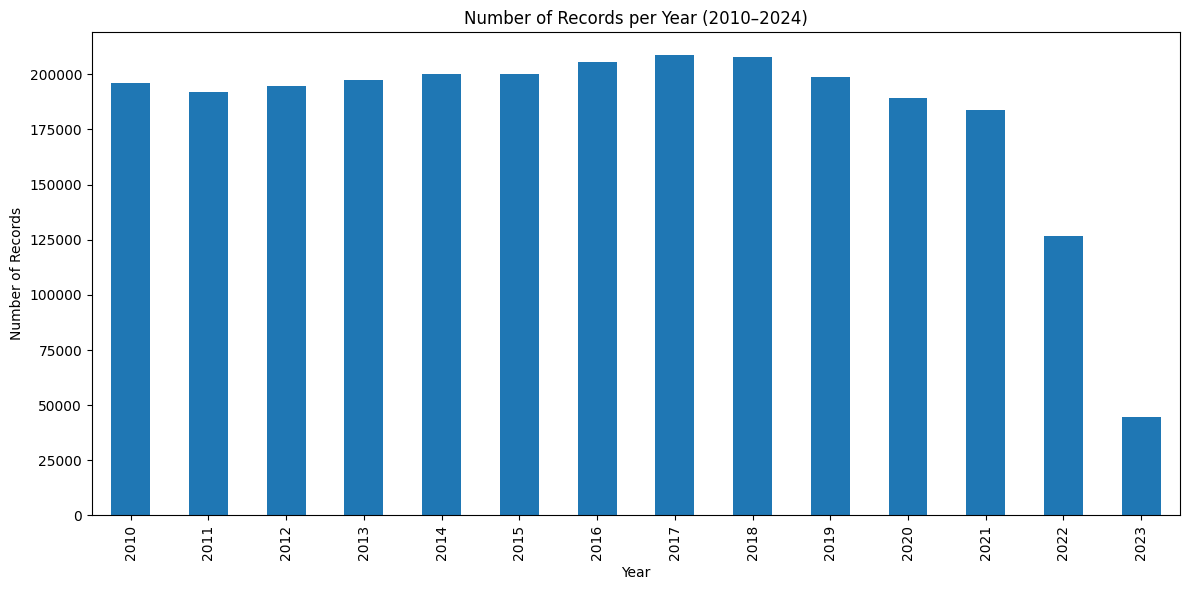

In [4]:
# Anzahl Zeilen pro Jahr berechnen
records_per_year = df_period.groupby("Year").size()

plt.figure(figsize=(12, 6))
records_per_year.plot(kind="bar")
plt.title("Number of Records per Year (2010–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Anzahl Einträge pro Land im Jahr 2017

In [5]:
# Filter data for the year 2017
df_2017 = df[df['Year'] == 2017]

df_2017.to_csv('Data_Files/data_2017.csv', index=False)



# Count the number of data entries for each country in 2017
country_data_counts = df_2017['Country'].value_counts()

print(country_data_counts)

Country
Brazil                               9230
Mexico                               6441
United States of America             6415
Iran (Islamic Republic of)           6205
Germany                              5589
Turkey                               4882
Argentina                            4876
Colombia                             4825
Spain                                4703
France                               4692
United Kingdom                       4647
Japan                                4610
Republic of Korea                    4348
United Kingdom, England and Wales    4333
Italy                                4297
Poland                               4232
Canada                               4004
Peru                                 3761
Ecuador                              3672
Thailand                             3496
Australia                            3456
Belgium                              3338
Czech Republic                       3261
Portugal                  

### Totale Todesfälle pro Land im Jahr 2017

In [6]:
# Nur Zeilen mit gültiger Cause behalten
df_2017 = df_2017[df_2017['Cause'].notna() & (df_2017['Cause'] != '')]

# Doppelte Einträge entfernen
unique_cols = ['Country', 'Sex', 'Cause', 'Year']
df_2017_unique = df_2017.drop_duplicates(subset=unique_cols)
df_2017_unique = df_2017_unique.copy()
# Summieren
result = (
    df_2017_unique
    .groupby('Country')['Deaths at all ages']
    .sum()
    .sort_values(ascending=False)
)

print(result)

Country
United States of America             2622466
Japan                                1340118
Brazil                               1196046
Germany                               932107
Italy                                 650455
Mexico                                634911
France                                591276
United Kingdom                        587481
United Kingdom, England and Wales     517086
Thailand                              435650
Spain                                 412878
Turkey                                411692
Poland                                388255
Iran (Islamic Republic of)            331815
Argentina                             330603
Republic of Korea                     267563
Canada                                261494
Romania                               255509
Colombia                              206127
Australia                             161075
Netherlands                           150194
Hungary                               126949
Gr

Country-Mapping für Subregionen, sowie mapping von Ländernamen, die in den zwei Datensätzen unterschiedlich benannt sind. Dies bietet uns die Grundlage die zwei Datensätze zusammenzuführen, und daraus die Todesfälle pro 100'000 Einwohner zu berechnen.

In [7]:
# Country-Mapping für Subregionen
country_map = {
    "United States of America": "United States",
    "Czech Republic": "Czechia",
    "Republic of Korea": "Korea, Republic of",
    "Republic of Moldova": "Moldova",
    "Turkey": "Türkiye",
    "Venezuela": "Venezuela, Bolivarian Republic of",

    # UK Subs

    # China / France Subregions
    "Hong Kong SAR": "Hong Kong",
    "Reunion": "France",
    "Guadeloupe": "France",
    "Martinique": "France",
    "Mayotte": "France",
    "French Guiana": "France",
    "Rodrigues": "Mauritius",
    "Puerto Rico": "United States",
    "Virgin Islands (USA)": "United States",

    # Caribbean and small states
    "Saint Vincent and Grenadines": "Saint Vincent and the Grenadines",
    "Saint Lucia": "Saint Lucia",
    "Saint Kitts and Nevis": "Saint Kitts and Nevis",
    "Grenada": "Grenada",
    "Aruba": "Aruba",
    "Maldives": "Maldives",
    "Bermuda": "Bermuda",
    "Belize": "Belize",
    "British Virgin Islands": "British Virgin Islands",
    "Turks and Caicos Islands": "Turks and Caicos Islands",
    "Montserrat": "Montserrat",
    "Antigua and Barbuda": "Antigua and Barbuda",
    "Cayman Islands": "Cayman Islands"
}

df_2017_unique["Country_clean"] = df_2017_unique["Country"].replace(country_map)

# ISO3 Codes generieren

def name_to_iso3(country_name):
    try:
        result = pycountry.countries.lookup(country_name)
        return result.alpha_3
    except:
        return None

df_2017_unique["ISO3"] = df_2017_unique["Country_clean"].apply(name_to_iso3)


# World Bank Population-Daten einlesen

pop_raw = pd.read_csv("Data_Files/API_SP.POP.TOTL_DS2_en_csv_v2_280659.csv", skiprows=4)

pop_2017 = pop_raw[["Country Code", "2017"]].rename(columns={"Country Code": "ISO3", "2017": "Population"})


# Merge WHO + Population

df_merged = df_2017_unique.merge(pop_2017,on="ISO3",how="inner")

# Todesfälle pro 100k berechnen

df_merged["Deaths_per_100k"] = (df_merged["Deaths at all ages"] / df_merged["Population"] * 100000)


# Für Boxplot aggregieren

mortality_per_country = (df_merged.groupby("ISO3")["Deaths_per_100k"].sum().reset_index())

print(mortality_per_country.sort_values("Deaths_per_100k", ascending=False))

   ISO3  Deaths_per_100k
7   BGR      1584.221459
46  LTU      1412.138509
48  LVA      1393.076476
36  HUN      1305.152509
64  ROU      1304.368357
35  HRV      1278.094485
49  MDA      1276.536746
29  GEO      1256.919252
30  GRC      1133.683302
20  DEU      1127.680629
26  EST      1114.709151
38  ITA      1084.050979
40  JPN      1055.443720
19  CZE      1051.882129
62  PRT      1036.290205
61  POL      1022.400998
68  SVK       944.140643
75  URY       938.780642
6   BEL       919.758653
22  DNK       918.043081
5   AUT       915.901057
69  SWE       915.438105
27  FRA       902.574523
16  CUB       900.929415
28  GBR       890.581512
2   ARM       886.957105
25  ESP       886.551595
56  NLD       876.722929
21  DMA       838.005139
76  USA       812.103517
72  TTO       779.355950
54  MUS       778.172279
77  VCT       772.266546
12  CHE       754.143476
1   ARG       746.469307
8   BMU       743.968039
52  MLT       742.872068
31  GRD       736.325993
11  CAN       715.538277


# PART2 EXPLORATIVE STATISTIK

### MMM
Wir berechnen Mittelwert, Median und Modus der Todesfälle pro 100'000 Einwohner, um einen Überblick über die zentrale Tendenz der Daten zu erhalten.
Da der Mittelwert über dem Median liegt, handelt es sich um eine rechtsschiefe Verteilung.

### Streuung
Wir berechnen die Standardabweichung, Varianz und den Interquartilsabstand (IQR), um die Streuung der Todesfälle pro 100'000 Einwohner zu quantifizieren. und damit wir Aussreisser identifizieren können.

### Outlier (Tukey + Modified Z)
Wir identifizieren Ausreisser in den Daten mithilfe der Tukey-Methode und der Modified Z-Score Methode. Dies hilft uns, ungewöhnliche Länder mit extrem hohen oder niedrigen Todesfällen pro 100'000 Einwohner zu erkennen.
Unsere Berechnungen zeigen, dass es keine Ausreisser in den Daten gibt, was darauf hindeutet, dass die Todesfälle pro 100'000 Einwohner relativ konsistent über die Länder verteilt sind.



### Boxplot & Violinplot
Um die oben genannten Statistiken zu visualisieren, erstellen wir einen Boxplot sowie einen Violinplot der Todesfälle pro 100'000 Einwohner. Der Boxplot zeigt die Verteilung der Daten, den Median, die Quartile und mögliche Ausreisser auf einen Blick.
Der Violinplot ergänzt den Boxplot, indem er die Dichteverteilung der Todesfälle pro 100'000 Einwohner darstellt. Dies gibt uns ein besseres Verständnis der Verteilung und Häufigkeit der Todesfälle in den verschiedenen Ländern.



--- Lage & Streuung ---
Mittelwert: 712.51
Median:     665.84
Std-Abw:    337.92
IQR:        471.67

--- Tukey Outliers ---
Empty DataFrame
Columns: [ISO3, Deaths_per_100k]
Index: []

--- Modified Z Outliers ---
Empty DataFrame
Columns: [ISO3, Deaths_per_100k]
Index: []

--- Zusammenfassung ---
     Statistic        Value
0         Mean   712.512959
1       Median   665.842613
2      Std Dev   337.922507
3          IQR   471.667304
4  Lower Fence  -262.196191
5  Upper Fence  1624.473025


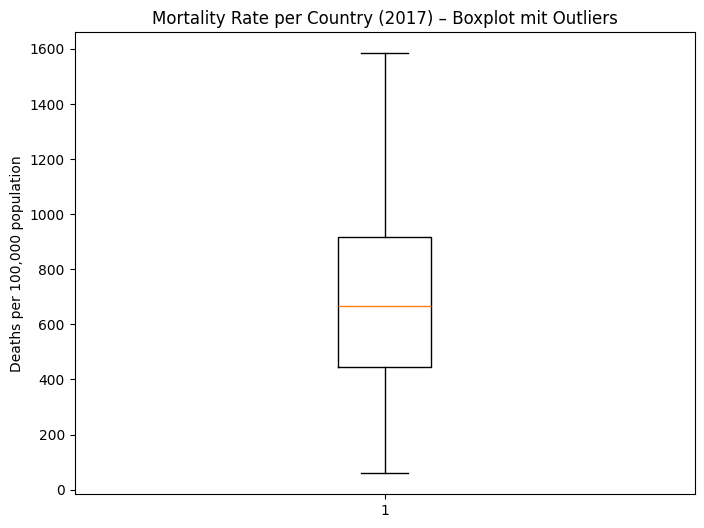

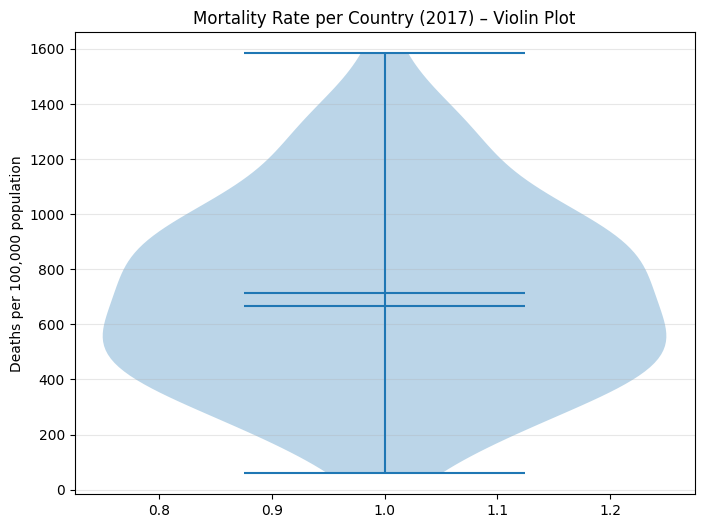

In [8]:
# Werte extrahieren
values = mortality_per_country["Deaths_per_100k"]

# Lage & Streuung
mean_val = values.mean()
median_val = values.median()
std_val = values.std()
iqr_val = values.quantile(0.75) - values.quantile(0.25)

print("\n--- Lage & Streuung ---")
print(f"Mittelwert: {mean_val:.2f}")
print(f"Median:     {median_val:.2f}")
print(f"Std-Abw:    {std_val:.2f}")
print(f"IQR:        {iqr_val:.2f}")


# Outliers nach Tukey Fences
Q1 = values.quantile(0.25)
Q3 = values.quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

tukey_outliers = mortality_per_country[(mortality_per_country["Deaths_per_100k"] < lower_fence) |(mortality_per_country["Deaths_per_100k"] > upper_fence)][["ISO3", "Deaths_per_100k"]]

print("\n--- Tukey Outliers ---")
print(tukey_outliers)


#Outliers nach Modified Z-Score
median_val = values.median()
MAD = np.median(np.abs(values - median_val))

mod_z = 0.6745 * (values - median_val) / MAD

modz_outliers = mortality_per_country[np.abs(mod_z) > 3.5][["ISO3", "Deaths_per_100k"]]

print("\n--- Modified Z Outliers ---")
print(modz_outliers)

#Zusammenfassende Tabelle
summary_table = pd.DataFrame({"Statistic": ["Mean", "Median", "Std Dev", "IQR", "Lower Fence", "Upper Fence"],"Value": [mean_val, median_val, std_val, iqr_val, lower_fence, upper_fence]})

print("\n--- Zusammenfassung ---")
print(summary_table)


# Boxplot mit Outlier-Markierung (optional, aber schön)
plt.figure(figsize=(8,6))
plt.boxplot(values, vert=True)

# Outlier-Labels
outliers = tukey_outliers["Deaths_per_100k"].values
for o in outliers:
    plt.scatter(1, o, color="red")

plt.title("Mortality Rate per Country (2017) - Boxplot mit Outliers")
plt.ylabel("Deaths per 100,000 population")
plt.show()


plt.figure(figsize=(8,6))
plt.violinplot(values, vert=True, showmeans=True, showextrema=True, showmedians=True)

plt.title("Mortality Rate per Country (2017) - Violin Plot")
plt.ylabel("Deaths per 100,000 population")
plt.grid(axis="y", alpha=0.3)

plt.show()



### Boxplot für jede Altersgruppe
Da sich unser Datensatz in verschiedene Altersgruppen unterteilen lässt, erstellen wir für jede Altersgruppe einen eigenen Boxplot der Todesfälle pro 100'000 Einwohner. Dies ermöglicht uns, die Verteilung der Todesfälle in den verschiedenen Altersgruppen zu vergleichen und mögliche Unterschiede oder Trends zu erkennen. Wir haben den Boxplot einmal in der üblichen Form und einmal in der Tuftes Form.

['Deaths at age 0', 'Deaths at age 1', 'Deaths at age 2', 'Deaths at age 3', 'Deaths at age 4', 'Deaths at age 5-9', 'Deaths at age 10-14', 'Deaths at age 15-19', 'Deaths at age 20-24', 'Deaths at age 25-29', 'Deaths at age 30-34', 'Deaths at age 35-39', 'Deaths at age 40-44', 'Deaths at age 45-49', 'Deaths at age 50-54', 'Deaths at age 55-59', 'Deaths at age 60-64', 'Deaths at age 65-69', 'Deaths at age 70-74', 'Deaths at age 75-79', 'Deaths at age 80-84', 'Deaths at age 85-89', 'Deaths at age 90-94', 'Deaths at age 95 years and above', 'Deaths at age unspecified']


C:\Users\benma\AppData\Local\Temp\ipykernel_28572\1379813009.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rate_only.values, labels=age_cols, vert=True)


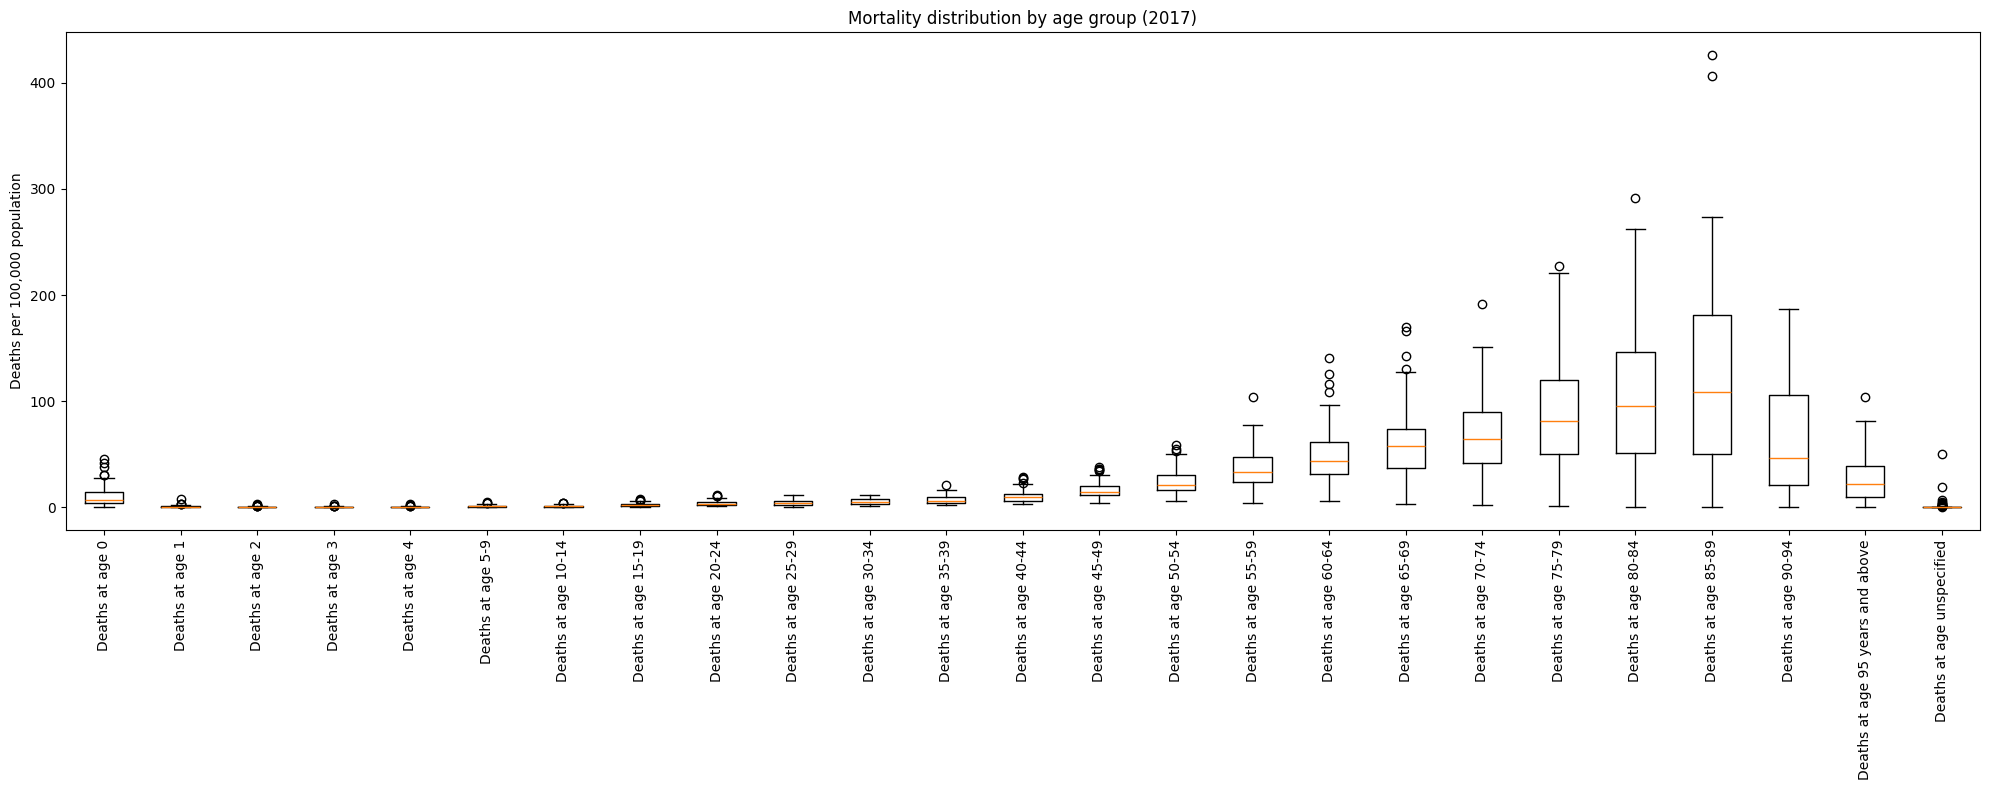

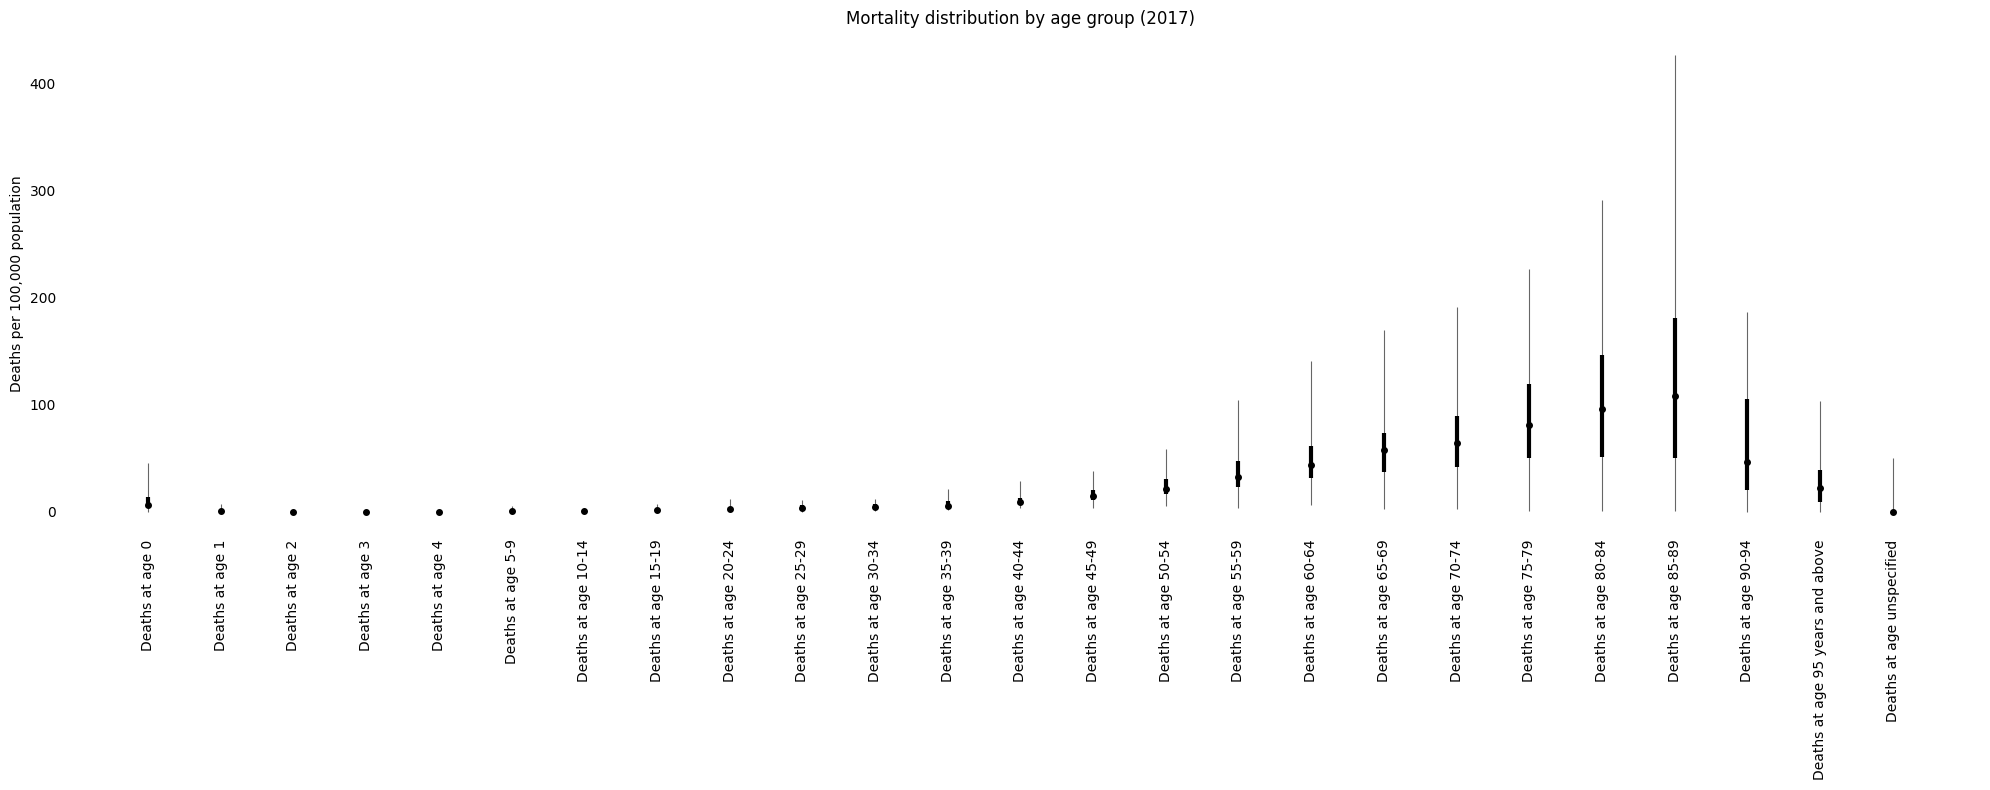

In [9]:
#finde alle Spalten, die mit "Deaths at age" beginnen
age_cols = [col for col in df_2017_unique.columns if "Deaths at age" in col]

print(age_cols)

#Summe pro Land (alle Causes zusammen)
age_by_country = df_2017_unique.groupby("ISO3")[age_cols].sum().reset_index()

age_by_country = age_by_country.merge(pop_2017, on="ISO3", how="inner")

for col in age_cols:
    age_by_country[col] = (age_by_country[col] / age_by_country["Population"] * 100000)

rate_only = age_by_country[age_cols]

## Normaler Boxplot
plt.figure(figsize=(20, 8))
plt.boxplot(rate_only.values, labels=age_cols, vert=True)

plt.xticks(rotation=90)
plt.ylabel("Deaths per 100,000 population")
plt.title("Mortality distribution by age group (2017)")

plt.tight_layout()
plt.show()

## Tuftes Boxplot
data = rate_only.values.T 
labels = age_cols

fig, ax = plt.subplots(figsize=(20, 8))

x = np.arange(len(data))

for xi, values in zip(x, data):
    q1 = np.percentile(values, 25)
    med = np.percentile(values, 50)
    q3 = np.percentile(values, 75)
    vmin = values.min()
    vmax = values.max()

    #Min–Max (lange vertikale Linie)
    ax.vlines(xi, vmin, vmax, color="black", linewidth=0.8, alpha=0.6)

    # Q1–Q3 (kurze vertikale Linie)
    ax.vlines(xi, q1, q3, color="black", linewidth=3)

    #Median (Punkt)
    ax.plot(xi, med, "o", color="black", markersize=4)

#Achsen
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.set_ylabel("Deaths per 100,000 population")
ax.set_title("Mortality distribution by age group (2017)")

#Tufte-Minimalismus
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()





### Deep Dive Ausreisser Kategorie "Deaths at age 0"
Uns hat es Wunder genommen welche Länder von einer aussergewöhnlich hohe Säuglingssterblichkeit betroffen sind. Dafür untersuchten wir die Ausreisser dieser Kategorie. Die Tukey Ausreisser und Modified Z Score Ausreisser stimmen überein. 
Es handelt sich um folgende Länder:
Dominikanische Republik,
Guatemala,
Kirgisistan,
Mongolei,
Nicaragua


In [10]:
# Werte holen
age0_values = age_by_country["Deaths at age 0"]
iso_codes = age_by_country["ISO3"]

# Lage & Streuung
mean_age0 = age0_values.mean()
median_age0 = age0_values.median()
std_age0 = age0_values.std()
iqr_age0 = age0_values.quantile(0.75) - age0_values.quantile(0.25)

print("\nStatistics for Deaths at age 0 (per 100k)")
print(f"Mean: {mean_age0:.2f}")
print(f"Median: {median_age0:.2f}")
print(f"Std Dev: {std_age0:.2f}")
print(f"IQR: {iqr_age0:.2f}")


# Tukey Outliers
Q1 = age0_values.quantile(0.25)
Q3 = age0_values.quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

tukey_mask = (age0_values < lower_fence) | (age0_values > upper_fence)
tukey_outliers = age_by_country.loc[tukey_mask, ["ISO3", "Deaths at age 0"]]

print("\nTukey Outliers (Infant Mortality)")
print(tukey_outliers)


# Modified Z-Score Outliers
median_val = median_age0
MAD = np.median(np.abs(age0_values - median_val))
mod_z = 0.6745 * (age0_values - median_val) / MAD

modz_mask = np.abs(mod_z) > 3.5
modz_outliers = age_by_country.loc[modz_mask, ["ISO3", "Deaths at age 0"]]

print("\nModified Z Outliers (Infant Mortality)")
print(modz_outliers)


# Sortierte Darstellung
sorted_age0 = age_by_country[["ISO3", "Deaths at age 0"]].sort_values("Deaths at age 0")
print("\nSorted Infant Mortality (Lowest → Highest)")
print(sorted_age0)



Statistics for Deaths at age 0 (per 100k)
Mean:      10.51
Median:    6.80
Std Dev:   9.61
IQR:       10.32

Tukey Outliers (Infant Mortality)
   ISO3  Deaths at age 0
23  DOM        42.055555
32  GTM        45.535326
41  KGZ        37.563250
53  MNG        30.073832
55  NIC        30.176224

Modified Z Outliers (Infant Mortality)
   ISO3  Deaths at age 0
23  DOM        42.055555
32  GTM        45.535326
41  KGZ        37.563250
53  MNG        30.073832
55  NIC        30.176224

Sorted Infant Mortality (Lowest → Highest)
   ISO3  Deaths at age 0
8   BMU         0.000000
18  CYP         0.877001
34  HKG         1.325542
40  JPN         1.386920
65  SGP         1.389816
42  KOR         1.851567
26  EST         2.201332
62  PRT         2.203819
38  ITA         2.223250
25  ESP         2.327617
47  LUX         2.515360
0   ABW         2.759001
69  SWE         2.783937
30  GRC         2.835975
19  CZE         2.869430
5   AUT         2.875795
46  LTU         2.990179
20  DEU         3.1104

# PART3 VERTEILUNGEN

### Histogramm + KDE
Wir erstellen ein Histogramm der Todesfälle pro 100'000 Einwohner, um die Verteilung der Daten visuell darzustellen. Zusätzlich fügen wir eine Kernel-Density-Estimation (KDE) Kurve hinzu, um die Dichteverteilung der Todesfälle zu veranschaulichen. Dies hilft uns, Muster und Trends in den Daten zu erkennen. Wir erkennen eine leicht rechtsschiefe Verteilung.

### ECDF
Wir erstellen eine Empirische Verteilungsfunktion (ECDF) der Todesfälle pro 100'000 Einwohner. Die ECDF zeigt den Anteil der Länder, die einen bestimmten Wert oder weniger an Todesfällen pro 100'000 Einwohner aufweisen. Dies ermöglicht uns, die Verteilung der Todesfälle in den verschiedenen Ländern zu vergleichen und zu verstehen, wie häufig bestimmte Werte auftreten. Man erkennt, dass die Mortalitätsraten von den meisten Ländern im Bereich von etwa 400 bis 900 Todesfällen pro 100'000 Einwohner liegen.

### QQ-Plot (zeigt Nicht-Normalverteilung)
Wir erstellen einen QQ-Plot (Quantile-Quantile-Plot), um die Verteilung der Todesfälle pro 100'000 Einwohner mit einer theoretischen Normalverteilung zu vergleichen. Im Zentralen Bereich liegen die Punkte nahe an der Diagonalen, was zeigt dass ein Teil der Daten normalverteilt sind. In der Unteren, sowie in der Oberen Quartilen weichen die Punkte von der Diagnoalen ab. Vorallem dass viele Punkte in der oberen Quartile über der Diagonalen liegen, deutet auf eine Rechts-Schiefe Verteilung hin. Dies bestätigt unsere vorherigen Erkenntnisse über die Verteilung der Todesfälle pro 100'000 Einwohner.

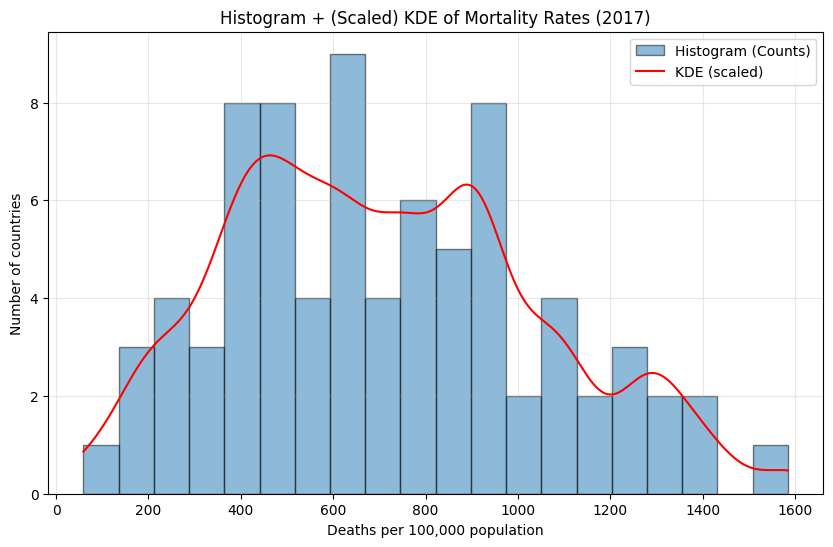

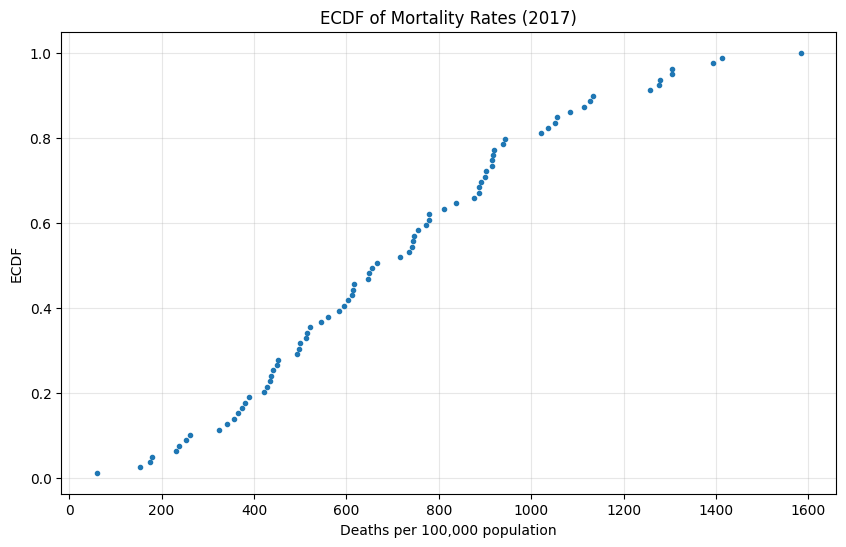

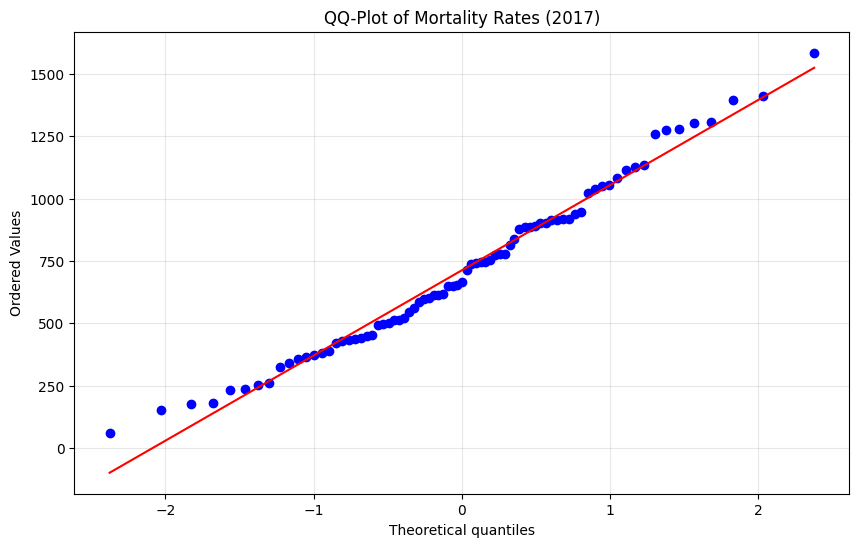

In [11]:
import scipy.stats as stats

values = mortality_per_country["Deaths_per_100k"]

plt.figure(figsize=(10, 6))

# Histogram (keine Dichte!)
plt.hist(values, bins=20, density=False, alpha=0.5, edgecolor="black", label="Histogram (Counts)")

# KDE
density = stats.gaussian_kde(values, bw_method=0.2)
x_vals = np.linspace(values.min(), values.max(), 500)

# Skalierung der KDE auf Histogrammhöhen:
kde_scaled = density(x_vals) * len(values) * ( (values.max()-values.min()) / 20 )

plt.plot(x_vals, kde_scaled, color="red", label="KDE (scaled)")

plt.xlabel("Deaths per 100,000 population")
plt.ylabel("Number of countries")
plt.title("Histogram + (Scaled) KDE of Mortality Rates (2017)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# ECDF
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

x_ecdf, y_ecdf = ecdf(values)

plt.figure(figsize=(10, 6))
plt.plot(x_ecdf, y_ecdf, marker='.', linestyle='none')
plt.xlabel("Deaths per 100,000 population")
plt.ylabel("ECDF")
plt.title("ECDF of Mortality Rates (2017)")
plt.grid(alpha=0.3)
plt.show()



# QQ-Plot

plt.figure(figsize=(10, 6))
stats.probplot(values, dist="norm", plot=plt)
plt.title("QQ-Plot of Mortality Rates (2017)")
plt.grid(alpha=0.3)
plt.show()


### Balkendiagramm mit den Länder und ihren Todesraten

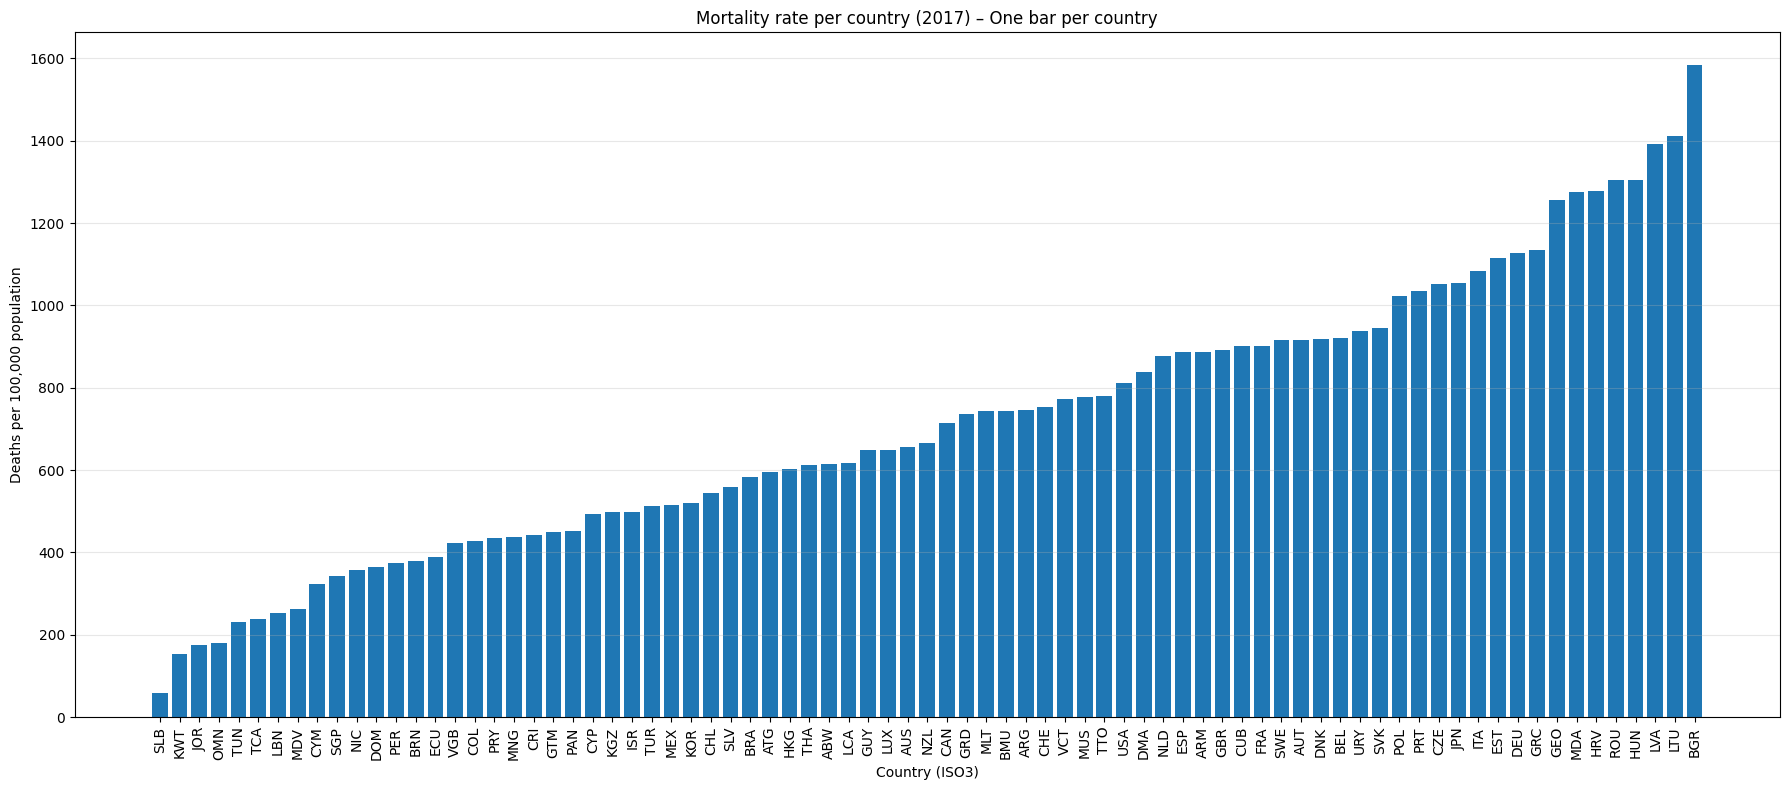

In [12]:
# Sortieren nach Todesrate (optional, sieht schöner aus)
mort_sorted = mortality_per_country.sort_values("Deaths_per_100k")

plt.figure(figsize=(18, 8))
plt.bar(mort_sorted["ISO3"], mort_sorted["Deaths_per_100k"])

plt.xlabel("Country (ISO3)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Mortality rate per country (2017) – One bar per country")

# X-Achse lesbarer machen
plt.xticks(rotation=90)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# PART4 KORRELATIONEN

## Korrelation MEDIAN AGE VS MORTALITY RATE

### Medianes Alter

Um den Zusammenhang zwischen dem medianen Alter der Bevölkerung und der Sterberate zu untersuchen, berechnen wir zunächst das mediane Alter für jedes Land. Dafür verwenden wir erneut Bevölkerungsdaten aus der World Bank Database.

Intuitiv könnte man erwarten, dass wohlhabendere Länder eine geringere Sterberate aufweisen als weniger wohlhabende Länder. Gleichzeitig ist davon auszugehen, dass wohlhabendere Länder aufgrund besserer medizinischer Versorgung und höherer Lebenserwartung eine ältere Bevölkerung haben. Daraus folgt, dass diese Länder tendenziell ein höheres medianes Alter besitzen.

Das mediane Alter wurde in dieser Analyse nicht direkt beobachtet, sondern mithilfe einer Näherung berechnet. Grundlage dafür ist die Altersstruktur der Bevölkerung, unterteilt in drei Altersgruppen. Der berechnete Wert stellt daher **kein exaktes medianes Alter**, sondern einen **approximativen Indikator für die Altersstruktur** eines Landes dar. Diese Näherung ist jedoch ausreichend, um generelle Zusammenhänge zwischen Altersstruktur und Sterberate zu analysieren.



    ISO3   pct_0_14  pct_15_64  pct_65plus  age_structure_index
34   CAF  49.025104  48.877373    2.097523            24.555849
229  TCD  48.398807  49.553699    2.047494            24.745016
173  NER  48.815270  48.711024    2.473706            24.756758
16   BDI  47.949414  49.734508    2.316077            24.987320
158  MLI  47.889300  49.534353    2.576347            25.098253
213  SOM  47.413915  50.124192    2.461893            25.215071
247  UGA  46.902204  51.114179    1.983617            25.216539
2    AFG  45.364605  52.275658    2.359737            25.855588
264  ZMB  44.509127  53.738010    1.752863            25.925490
43   COD  45.822635  51.073141    3.104224            25.965009
165  MOZ  45.474878  51.748491    2.776632            25.965111
19   BFA  45.122536  52.317978    2.559486            26.005383
4    AGO  45.250826  52.063932    2.685242            26.007062
216  SSD  45.046723  52.429759    2.523517            26.017812
168  MWI  44.641456  52.461364    2.8971

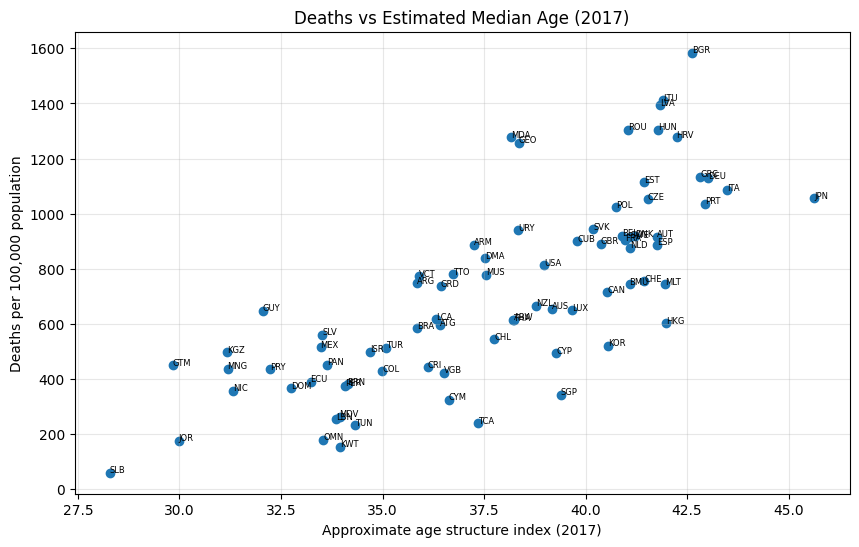

In [13]:
## Deats per 100k vs median age scatter plot
# -----------------------------     

#Daten Einlesen
age_0_14_raw = pd.read_csv("Data_Files/API_SP.POP.0014.TO.ZS_DS2_en_csv_v2_253632.csv", skiprows=4)
age_15_64_raw = pd.read_csv("Data_Files/API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_294218.csv", skiprows=4)
age_65_raw = pd.read_csv("Data_Files/API_SP.POP.65UP.TO.ZS_DS2_en_csv_v2_8582.csv", skiprows=4)


# 2017 Daten extrahieren
age_0_14 = age_0_14_raw[["Country Code", "2017"]].rename(columns={"Country Code": "ISO3", "2017": "pct_0_14"})

age_15_64 = age_15_64_raw[["Country Code", "2017"]].rename(columns={"Country Code": "ISO3", "2017": "pct_15_64"})

age_65 = age_65_raw[["Country Code", "2017"]].rename(columns={"Country Code": "ISO3", "2017": "pct_65plus"})

# Merge Altersdaten
age_all = age_0_14.merge(age_15_64, on="ISO3", how="inner") \
.merge(age_65, on="ISO3", how="inner")

#Median Age annäherung berechnen
age_all["age_structure_index"] = (7  * (age_all["pct_0_14"] / 100) +40 * (age_all["pct_15_64"] / 100) +75 * (age_all["pct_65plus"] / 100))


print(age_all.sort_values("age_structure_index"))

# Merge mit Mortalitätsdaten
scatter_data = mortality_per_country.merge(age_all, on="ISO3", how="inner")

# Scatter Plot erstellen
plt.figure(figsize=(10,6))

plt.scatter(scatter_data["age_structure_index"], scatter_data["Deaths_per_100k"])

plt.xlabel("Approximate age structure index (2017)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Deaths vs Estimated Median Age (2017)")

plt.grid(alpha=0.3)

# Option: Länderlabels anzeigen
for i, row in scatter_data.iterrows():
    plt.text(row["age_structure_index"], row["Deaths_per_100k"], row["ISO3"], fontsize=6)

plt.show()




Die Tendenz ist sichtbar und zwar dass je höher das Mediane Alter eines Landes, desto höher ist auch die Sterberate.

Wir untersuchen dies nun mit dem Spearman und Pearson Korrelationskoeffizienten. 

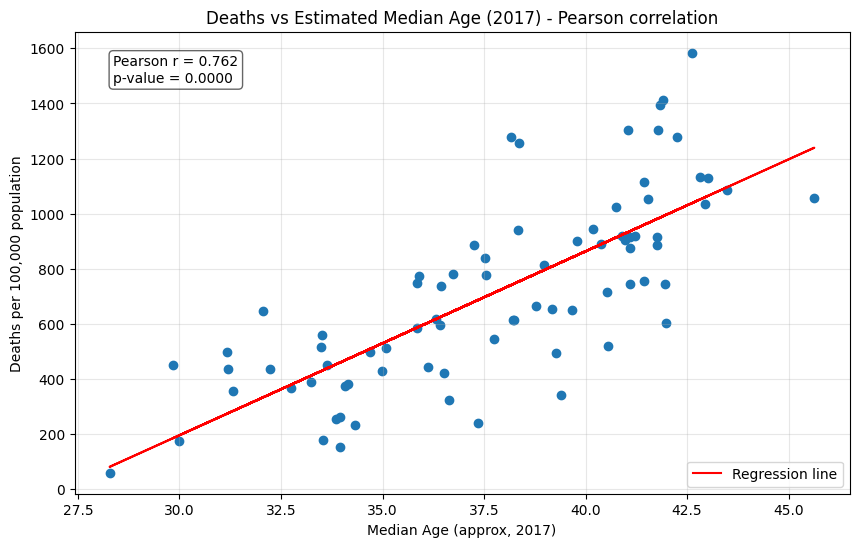

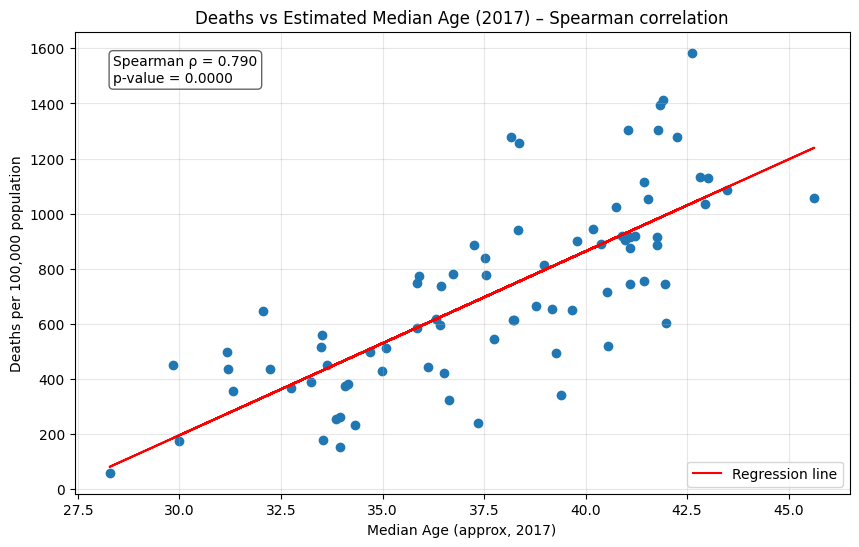

In [14]:
from scipy.stats import pearsonr, spearmanr


# Daten aus Median-Age-Proxy-Plot holen
x = scatter_data["age_structure_index"].values
y = scatter_data["Deaths_per_100k"].values

# Lineare Regression
slope, intercept = np.polyfit(x, y, 1)
reg_line = slope * x + intercept

# Pearson-Korrelation
corr, p_value = pearsonr(x, y)

# Plot
plt.figure(figsize=(10, 6))

# Scatterplot
plt.scatter(x, y)

# Regressionslinie
plt.plot(x, reg_line, color="red", label="Regression line")

# Labels
plt.xlabel("Median Age (approx, 2017)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Deaths vs Estimated Median Age (2017) - Pearson correlation")

# Korrelationsinfo ins Plot schreiben
plt.text(0.05, 0.95, f"Pearson r = {corr:.3f}\np-value = {p_value:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.grid(alpha=0.3)
plt.legend()
plt.show()


# Spearman-Korrelation
spearman_corr, spearman_p = spearmanr(x, y)

# Plot
plt.figure(figsize=(10, 6))

# Scatterplot
plt.scatter(x, y)

# Regressionslinie (optional, gleiche Linie wie vorher)
plt.plot(x, reg_line, color="red", label="Regression line")

# Labels
plt.xlabel("Median Age (approx, 2017)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Deaths vs Estimated Median Age (2017) - Spearman correlation")

# Korrelationsinfo ins Plot schreiben
plt.text(0.05, 0.95, f"Spearman ρ = {spearman_corr:.3f}\np-value = {spearman_p:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.grid(alpha=0.3)
plt.legend()
plt.show()



### Korrelationsanalyse

Die berechneten Korrelationskoeffizienten bestätigen die anfängliche Vermutung. Sowohl der Pearson- als auch der Spearman-Korrelationskoeffizient weisen auf einen starken positiven Zusammenhang zwischen der Altersstruktur der Bevölkerung und der Sterberate hin (Pearson: 0.762, Spearman: 0.790).

### Interpretation

Länder mit einer älteren Bevölkerungsstruktur weisen tendenziell höhere Sterberaten auf als Länder mit einer jüngeren Bevölkerung. Dieser Zusammenhang lässt sich dadurch erklären, dass die Mortalität mit zunehmendem Alter stark ansteigt. Wohlhabendere Länder verfügen häufig über eine höhere Lebenserwartung und damit über einen größeren Anteil älterer Personen in der Bevölkerung, was zu höheren aggregierten Sterberaten pro 100 000 Einwohner führt.


## Korrelation LIFE EXPECTANCY VS MORTALITY RATE

### Life Expectancy
Wor wollten überprüfen ob es demnach einen Zusammenhang gibt zwischen der Lebenserwartung eines Landes und der Sterberate.
Für die Lebenserwartung von den verschiedenen Ländern haben wir erneut die Bevölkerungsdaten aus der World Bank Database verwendet.


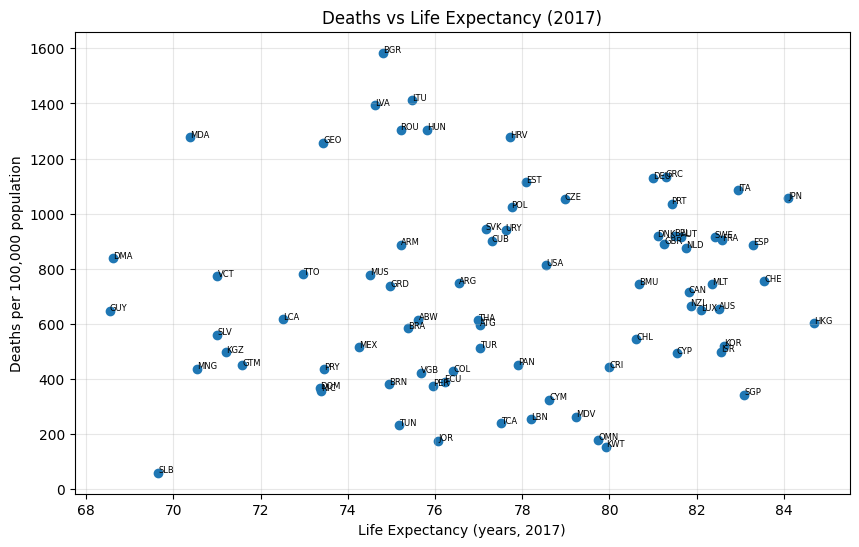

In [15]:
#Lebenserwartungs-Datei einlesen
life_raw = pd.read_csv("Data_Files/API_SP.DYN.LE00.IN_DS2_en_csv_v2_309535.csv", skiprows=4)

# 2. Nur ISO3 + Jahr 2017 extrahieren
life_2017 = life_raw[["Country Code", "2017"]].rename(columns={"Country Code": "ISO3", "2017": "LifeExpectancy"})

# 3. Merge mit deinen Mortalitätsdaten
scatter_life = mortality_per_country.merge(life_2017, on="ISO3", how="inner")

# Falls NaN-Werte drin sind -> rauswerfen
scatter_life = scatter_life.dropna(subset=["LifeExpectancy"])


# 4. Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(scatter_life["LifeExpectancy"], scatter_life["Deaths_per_100k"])

plt.xlabel("Life Expectancy (years, 2017)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Deaths vs Life Expectancy (2017)")

plt.grid(alpha=0.3)


# 5. Länderlabels anzeigen (optional)
for i, row in scatter_life.iterrows():
    plt.text(
        row["LifeExpectancy"],
        row["Deaths_per_100k"],
        row["ISO3"],
        fontsize=6
    )

plt.show()


Auf dem erstellten Scatterplot kann keine Tendenz beobatet werden. Wir überprüfen dies wiederum mit Spearman und Pearson

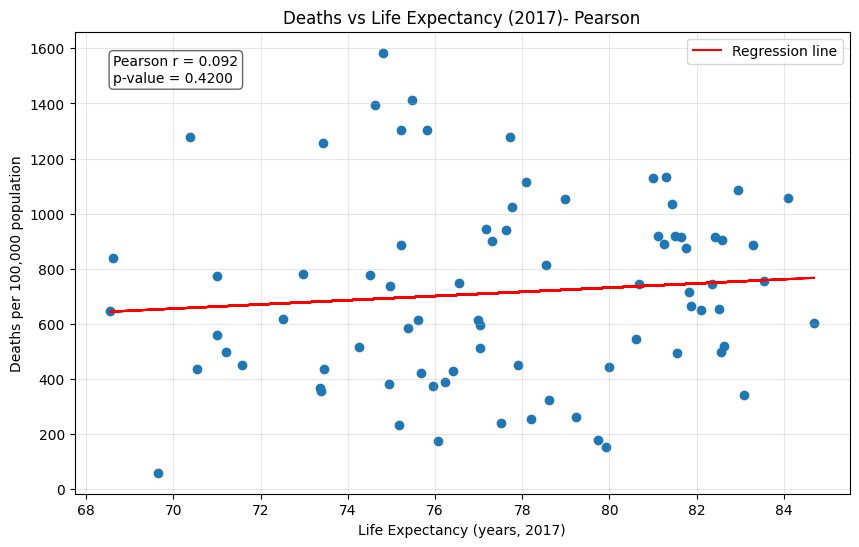

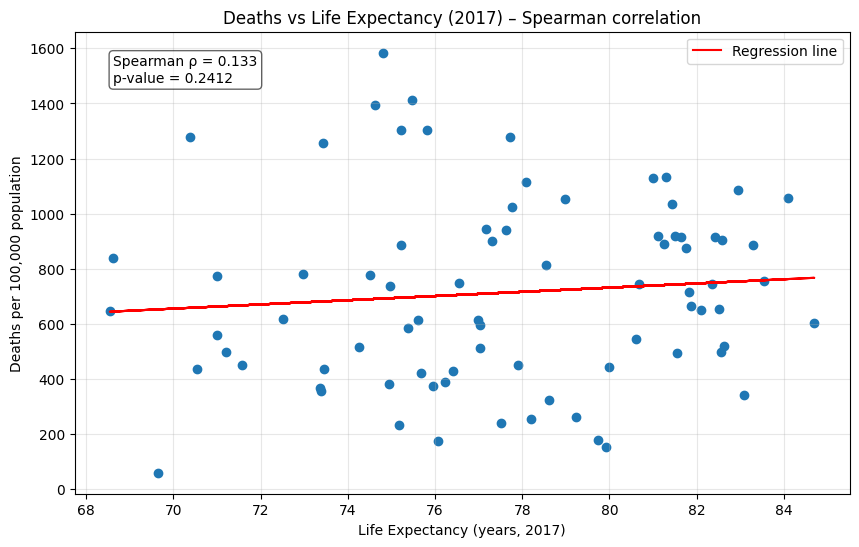

In [16]:

# Daten holen
x = scatter_life["LifeExpectancy"].values
y = scatter_life["Deaths_per_100k"].values


# Lineare Regression
slope, intercept = np.polyfit(x, y, 1)
reg_line = slope * x + intercept


# Pearson-Korrelation
corr, p_value = pearsonr(x, y)


# Plot
plt.figure(figsize=(10, 6))

# Scatterplot
plt.scatter(x, y)

# Regressionslinie
plt.plot(x, reg_line, color="red", label=f"Regression line")

# Labels
plt.xlabel("Life Expectancy (years, 2017)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Deaths vs Life Expectancy (2017)- Pearson")

# Korrelationsinfo ins Plot schreiben
plt.text(
    0.05, 0.95,
    f"Pearson r = {corr:.3f}\np-value = {p_value:.4f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.6)
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()



# ---------------------------
# Spearman-Korrelation
# ---------------------------
spearman_corr, spearman_p = spearmanr(x, y)

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(10, 6))

# Scatterplot
plt.scatter(x, y)

# Regressionslinie (gleiche lineare Linie wie zuvor)
plt.plot(x, reg_line, color="red", label="Regression line")

# Labels
plt.xlabel("Life Expectancy (years, 2017)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Deaths vs Life Expectancy (2017) – Spearman correlation")

# Korrelationsinfo ins Plot schreiben
plt.text(
0.05, 0.95,f"Spearman ρ = {spearman_corr:.3f}\np-value = {spearman_p:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.grid(alpha=0.3)
plt.legend()
plt.show()

Die Korrelations Koeffizienten bestätigen unsere Tendenz, nähmlich dass der Lineare Zusammenhang sehr schwach ist (Pearson: 0.092, Spearman: 0.133)

### Interpretation
Die Korrelation von LIFE EXPECTANCY VS MORTALITY RATE lässti sich nicht übertragen auf MEDIAN AGE VS MORTALITY RATE. Dies aus dem Grund dass die Lebenserwartung nur wenig über die aktuelle Demografie eines Landes aussagt.

***Länder mit hoher LE, aber tiefen Sterberaten***
→ junge, gesunde Bevölkerungen
→ SGP, CHL, AUS, CAN etc.

***Länder mit hoher LE, aber hohen Sterberaten***
→ sehr alte Bevölkerungen
→ ITA, ESP, JPN, CHE, PRT etc.

***Länder mit niedriger LE, aber tiefen Sterberaten***
→ junge, aber ärmere Länder
→ MAR, MNG, PER, GTM, IND

***Länder mit niedriger LE, aber hohen Sterberaten***
→ selten, aber möglich
→ GEO, BGR, LVA

# PART5 GRUPPENVERGLEICHE
### Sterberate pro Kontinent
Wir wollten wissen ob es kontinente gibt, wo sich die Sterberate signifikant voneinander unterscheidet oder nicht. Daführ haben wir einen Hypothesentest (Kruskall Wallis) durgeführt. Wir haben uns für Kruskall Wallis entschieden weil unsere Daten nicht normalverteilt sind

Kruskal–Wallis H-test
----------------------
H-statistic: 41.251
p-value:     0.00000


C:\Users\benma\AppData\Local\Temp\ipykernel_28572\3196718014.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups_ordered, labels=order)


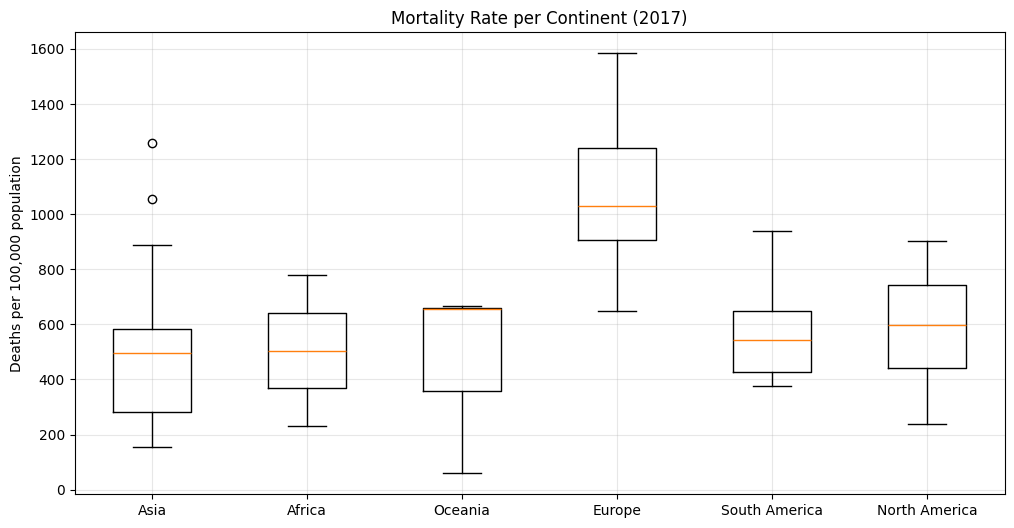

In [17]:
import pycountry_convert as pc

continent_map = {
    "AF": "Africa",
    "AS": "Asia",
    "EU": "Europe",
    "NA": "North America",
    "SA": "South America",
    "OC": "Oceania"
}

# 1. Funktion: ISO3 → Kontinent
def iso3_to_continent(iso3):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        cont = pc.country_alpha2_to_continent_code(iso2)
        return cont
    except:
        return None

continent_map = {
    "AF": "Africa",
    "AS": "Asia",
    "EU": "Europe",
    "NA": "North America",
    "SA": "South America",
    "OC": "Oceania"
}


# 2. Kontinent-Spalte erzeugen
mortality_per_country["Continent"] = mortality_per_country["ISO3"].apply(iso3_to_continent)
mortality_per_country["Continent"] = mortality_per_country["Continent"].map(continent_map)

# Länder ohne Kontinent entfernen
mortality_clean = mortality_per_country.dropna(subset=["Continent"])

# 3. Daten pro Kontinent sammeln
groups = mortality_clean.groupby("Continent")["Deaths_per_100k"].apply(list)


# 3. Daten pro Kontinent sammeln + Reihenfolge
order = ["Asia", "Africa", "Oceania", "Europe", "South America", "North America"]

# Gefiltert nach Kontinenten in der gewünschten Reihenfolge
groups_ordered = [mortality_clean[mortality_clean["Continent"] == cont]["Deaths_per_100k"].tolist()for cont in order]


# 4. Kruskal–Wallis-Test
stat, p = stats.kruskal(*groups_ordered)

print("Kruskal-Wallis H-test")
print("----------------------")
print(f"H-statistic: {stat:.3f}")
print(f"p-value:     {p:.5f}")

# 5. Boxplot visualisieren
plt.figure(figsize=(12, 6))
plt.boxplot(groups_ordered, labels=order)
plt.title("Mortality Rate per Continent (2017)")
plt.ylabel("Deaths per 100,000 population")
plt.grid(alpha=0.3)
plt.show()



### Hypothesen
H0: Es gibt keinen Unterschied in der Mortalitätsrate zwischen den Kontinenten.
H1: Es gibt einen Unterschied in der Mortalitätsrate zwischen den Kontinenten.

### Ergebnis
H-statistic: 41.794
p-value: 0.00000
Schlussfolgerung: Da der p-Wert kleiner als 0.05 ist, lehnen wir die Nullhypothese ab und schließen, dass es einen signifikanten Unterschied in der Mortalitätsrate zwischen mindestens zwei Kontinenten gibt. um rauszufinden welche Kontinente sich unterscheiden, können wir Post-hoc-Tests wie den Dunn-Test durchführen. Da wir für Asien, Afrika und Ozeanien extrem wenige Daten zur Verfügung haben haben wir sie in unserem Post-hoc-Test ausgeschlossen.


Anzahl Länder nach Filter: 56
  ISO3 Continent  Deaths_per_100k
0  ABW        NA       615.257277
1  ARG        SA       746.469307
3  ATG        NA       595.790777
5  AUT        EU       915.901057
6  BEL        EU       919.758653
              EU            NA        SA
EU  1.000000e+00  3.948596e-07  0.000073
NA  3.948596e-07  1.000000e+00  0.902788
SA  7.294484e-05  9.027879e-01  1.000000


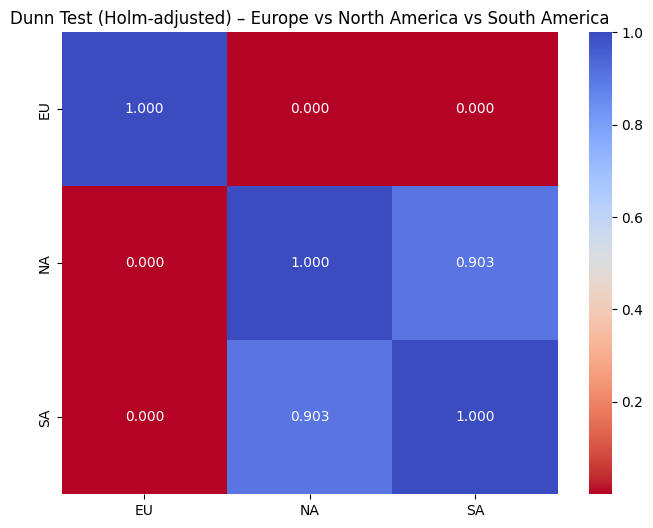

In [18]:
import scikit_posthocs as sp

# ISO3 → Continent Mapping
df_merged["Continent"] = df_merged["ISO3"].apply(iso3_to_continent)

# Länderlevel aggregieren
country_level = (df_merged.groupby(["ISO3", "Continent"])["Deaths_per_100k"].sum().reset_index())

# Nur gewünschte Kontinente behalten
keep_continents = ["EU", "NA", "SA"]

filtered = country_level[country_level["Continent"].isin(keep_continents)].copy()

# Reihenfolge fixieren
filtered.loc[:, "Continent"] = pd.Categorical(filtered["Continent"],categories=keep_continents, ordered=True)

print("Anzahl Länder nach Filter:", filtered.shape[0])
print(filtered.head())

# Dunn-Test
dunn = sp.posthoc_dunn(filtered, val_col="Deaths_per_100k", group_col="Continent", p_adjust="holm")

print(dunn)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(dunn, annot=True, cmap="coolwarm_r", fmt=".3f")
plt.title("Dunn Test (Holm-adjusted) - Europe vs North America vs South America")
plt.show()


### Interpretation
EU vs NA ≈ 0.0000004  → hochsignifikant 

EU vs SA ≈ 0.00007    → hochsignifikant

NA vs SA ≈ 0.90       → kein signifikanter Unterschied


# PART6 SIMPSON'S PARADOX

Bei Analysen mit aggregierten Länderdaten kann es vorkommen, dass beobachtete Zusammenhänge durch strukturelle Unterschiede zwischen Gruppen verzerrt werden. Das Simpson-Paradoxon beschreibt genau diesen Effekt: Ein Zusammenhang, der im Gesamtdatensatz stark erscheint, kann innerhalb einzelner Teilgruppen deutlich schwächer sein oder sogar verschwinden. Daher ist es sinnvoll zu prüfen, ob der Zusammenhang zwischen Altersstruktur und Sterberate auch innerhalb von Kontinenten besteht oder hauptsächlich durch Unterschiede zwischen Kontinenten entsteht.

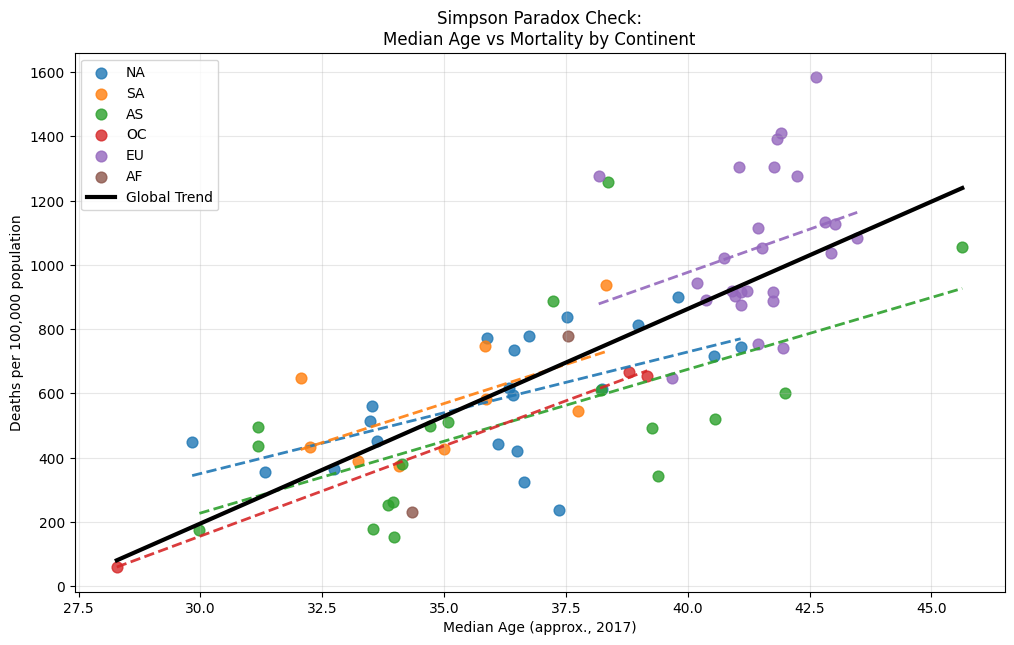

In [19]:
from scipy.stats import linregress

df = scatter_data.copy()
df["Continent"] = df["ISO3"].apply(iso3_to_continent)

plt.figure(figsize=(12, 7))
continents = df["Continent"].unique()

palette = sns.color_palette("tab10", len(continents))

# Einzelne Trendlinien pro Kontinent
for color, cont in zip(palette, continents):
    subset = df[df["Continent"] == cont]

    plt.scatter(subset["age_structure_index"], subset["Deaths_per_100k"], label=cont, color=color, s=60, alpha=0.8)

    if len(subset) > 2:
        sx = subset["age_structure_index"]
        sy = subset["Deaths_per_100k"]

        slope_c, intercept_c, _, _, _ = linregress(sx, sy)
        xs = np.linspace(sx.min(), sx.max(), 50)

        plt.plot(xs, slope_c * xs + intercept_c, color=color, linestyle="--", linewidth=2, alpha=0.9)

# Gesamtlinie (globaler Trend)
slope, intercept = np.polyfit(df["age_structure_index"], df["Deaths_per_100k"], 1)

xs = np.linspace(df["age_structure_index"].min(), df["age_structure_index"].max(), 100)

plt.plot(xs, slope * xs + intercept, color="black", linewidth=3, label="Global Trend")

plt.xlabel("Median Age (approx., 2017)")
plt.ylabel("Deaths per 100,000 population")
plt.title("Simpson Paradox Check:\nMedian Age vs Mortality by Continent")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


### Interpretation

Der globale Trend zeigt einen klar positiven Zusammenhang zwischen dem approximierten medianen Alter und der Sterberate. Länder mit älterer Bevölkerungsstruktur weisen insgesamt höhere Sterberaten auf.

Betrachtet man jedoch die einzelnen Kontinente getrennt, sind die Trendlinien innerhalb der Kontinente deutlich flacher. Der starke globale Zusammenhang wird somit teilweise durch Unterschiede zwischen den Kontinenten erklaert. Dies deutet auf ein partielles Simpson-Paradoxon hin und zeigt, dass aggregierte Analysen den Zusammenhang zwischen Alter und Sterberate überschätzen können.